## Lab6-Assignment: Topic Classification

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb 

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice. 
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from collections import Counter
from sklearn.model_selection import train_test_split

In [30]:
import re
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#### Data preprocessing for RoBERTa

In [7]:
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

training_set = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
testing_set = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

print(f"Training set: {Counter(training_set.target)}")
print(f"Testing set: {Counter(testing_set.target)}")

Training set: Counter({2: 594, 3: 593, 1: 584, 0: 480})
Testing set: Counter({2: 396, 3: 394, 1: 389, 0: 319})


In [8]:
train_dataframe = pd.DataFrame({'text': training_set.data, 'labels': training_set.target})
print(len(train_dataframe))
train_dataframe.head(5)

2251


,text,labels
0,WHile we are on the subject of the shuttle sof...,3
1,There is a program called Graphic Workshop you...,1
2,,2
3,My girlfriend is in pain from kidney stones. S...,2
4,I think that's the correct spelling..\n\tI am ...,2


In [9]:
test_dataframe = pd.DataFrame({'text': testing_set.data, 'labels': testing_set.target})
print(len(test_dataframe))
test_dataframe.head(5)

1498


,text,labels
0,\nAnd guess who's here in your place.\n\nPleas...,1
1,Does anyone know if any of Currier and Ives et...,1
2,=FLAME ON\n=\n=Reading through the posts about...,2
3,\nBut in this case I said I hoped that BCCI wa...,0
4,\nIn the kind I have made I used a Lite sour c...,2


In [10]:
training, testing = train_test_split(train_dataframe, test_size=0.1, random_state=0, stratify=train_dataframe[['labels']])

print(f"Training set length: {len(training)}")
print(f"Testing set length: {len(testing)}")
print()
print(f"train: {training[['labels']].value_counts(sort=False)}")
print(f"test: {testing[['labels']].value_counts(sort=False)}")
print()
print(training.head(3))
print(testing.head(3))

Training set length: 2025
Testing set length: 226

train: labels
0         432
1         525
2         534
3         534
Name: count, dtype: int64
test: labels
0         48
1         59
2         60
3         59
Name: count, dtype: int64

                                                   text  labels
559   I wonder how many atheists out there care to s...       0
2060  We are interested in purchasing a grayscale pr...       1
1206  Dear Binary Newsers,\n\nI am looking for Quick...       1
                                                   text  labels
1570  I'd dump him.  Rude is rude and it seems he en...       2
1761  Hi Everyone ::\n\nI am  looking for  some soft...       1
455   A friend of mine has been diagnosed with Psori...       2


## Using RoBERTa for topic classification

In [11]:
# Model configuration

roberta_args = ClassificationArgs()

roberta_args.overwrite_output_dir=True
roberta_args.evaluate_during_training=True

roberta_args.num_train_epochs=10
roberta_args.train_batch_size=32
roberta_args.learning_rate=4e-6
roberta_args.max_seq_length=256

roberta_args.use_early_stopping=True
roberta_args.early_stopping_delta=0.01

roberta_args.early_stopping_metric='eval_loss'
roberta_args.early_stopping_metric_minimize=True
roberta_args.early_stopping_patience=2
roberta_args.evaluate_during_training_steps=32

# Kept the same as BERT to equally compare the models

steps_per_epoch = int(np.ceil(len(training) / float(roberta_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch))

Each epoch will have 64 steps.


In [12]:
roberta_model = ClassificationModel('roberta', 'roberta-base', num_labels=4, args=roberta_args, use_cuda=False) 

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
#XLNet = ClassificationModel('xlnet', 'xlnet-base-cased', num_labels=4, args=roberta_args, use_cuda=False)

In [13]:
print(str(roberta_model.args).replace(',', '\n'))

ClassificationArgs(adafactor_beta1=None
 adafactor_clip_threshold=1.0
 adafactor_decay_rate=-0.8
 adafactor_eps=(1e-30
 0.001)
 adafactor_relative_step=True
 adafactor_scale_parameter=True
 adafactor_warmup_init=True
 adam_betas=(0.9
 0.999)
 adam_epsilon=1e-08
 best_model_dir='outputs/best_model'
 cache_dir='cache_dir/'
 config={}
 cosine_schedule_num_cycles=0.5
 custom_layer_parameters=[]
 custom_parameter_groups=[]
 dataloader_num_workers=0
 do_lower_case=False
 dynamic_quantize=False
 early_stopping_consider_epochs=False
 early_stopping_delta=0.01
 early_stopping_metric='eval_loss'
 early_stopping_metric_minimize=True
 early_stopping_patience=2
 encoding=None
 eval_batch_size=100
 evaluate_during_training=True
 evaluate_during_training_silent=True
 evaluate_during_training_steps=32
 evaluate_during_training_verbose=False
 evaluate_each_epoch=True
 fp16=False
 gradient_accumulation_steps=1
 learning_rate=4e-06
 local_rank=-1
 logging_steps=50
 loss_type=None
 loss_args={}
 manual_se

In [14]:
_, roberta_history = roberta_model.train_model(training, eval_df=testing)

  0%|          | 0/4 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Running Epoch 1 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Running Epoch 8 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

0it [00:00, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Model evaluation

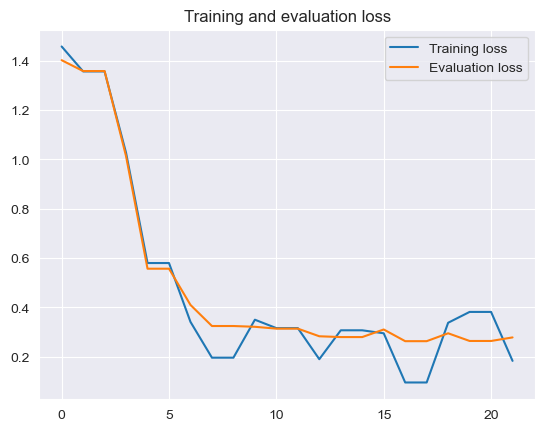

In [15]:
# Training and evaluation loss
train_loss = roberta_history['train_loss']
eval_loss = roberta_history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [25]:
result, model_outputs, wrong_predictions = roberta_model.eval_model(testing)
result

0it [00:00, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

{'mcc': 0.8475537969229284, 'eval_loss': 0.2784139464298884}

In [26]:
predicted, probabilities = roberta_model.predict(test_dataframe.text.to_list())
test_dataframe['predicted'] = predicted

  0%|          | 0/2 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  0%|          | 0/15 [00:00<?, ?it/s]

In [27]:
test_dataframe.head(5)

,text,labels,predicted
0,\nAnd guess who's here in your place.\n\nPleas...,1,1
1,Does anyone know if any of Currier and Ives et...,1,1
2,=FLAME ON\n=\n=Reading through the posts about...,2,2
3,\nBut in this case I said I hoped that BCCI wa...,0,0
4,\nIn the kind I have made I used a Lite sour c...,2,2


In [28]:
print(classification_report(test_dataframe['labels'], test_dataframe['predicted']))

              precision    recall  f1-score   support

           0       0.85      0.78      0.81       319
           1       0.90      0.90      0.90       389
           2       0.84      0.92      0.88       396
           3       0.83      0.81      0.82       394

    accuracy                           0.86      1498
   macro avg       0.86      0.85      0.85      1498
weighted avg       0.86      0.86      0.86      1498



#### Data preprocessing for SVM

In [40]:
data_train, labels_train = training_set.data, training_set.target
data_test, labels_test = testing_set.data, testing_set.target

vectorizer = TfidfVectorizer(max_features=99999999999999, stop_words='english')
data_train_tfidf = vectorizer.fit_transform(data_train)
data_test_tfidf = vectorizer.transform(data_test)

print(data_train_tfidf.shape)
print('-----------------------------------------------')
print(data_test_tfidf.shape)

(2251, 29764)
-----------------------------------------------
(1498, 29764)


## Using SVM with tfidf for topic classification

In [51]:
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(data_train_tfidf, labels_train)

SVC(kernel='linear')

In [52]:
y_pred = svm_model.predict(data_test_tfidf)

In [53]:
print(classification_report(labels_test, y_pred, target_names=categories))

               precision    recall  f1-score   support

  alt.atheism       0.85      0.75      0.80       319
comp.graphics       0.88      0.87      0.88       389
      sci.med       0.87      0.83      0.85       396
    sci.space       0.75      0.87      0.81       394

     accuracy                           0.83      1498
    macro avg       0.84      0.83      0.83      1498
 weighted avg       0.84      0.83      0.83      1498



## Comparison of results

The BERT-RoBERTa model scores a weighted average score of 0.86 for its precision, recall and f1-score, and the SVM scores a weighted average of 0.84 for precision and a score of 0.83 for recall and f1-score. This shows that on average BERT-RoBERTa outperforms SVM, thus on average,  BERT-RoBERTa is more accurate and precise.  
Looking more specifically at the results, for classifying as atheism, BERT and SVM score the same precision score, but BERT has a better recall score of 0.78 compared to 0.75. For the graphics topic, BERT had a higher precision and recall score. For the topic of medicine, BERT scored 0.84 for precision, and SVM scored 0.87 here. However, this is contrasted by their recall scores of 0.92 and 0.83, respectively; the higher F1 score for BERT shows that the higher recall score was enough to compensate for this. A similar but reversed instance is present when assessing the scores for the space topic. Here, BERT underperforms based on the Recall score, however, based on the F1-score compensates for this with a higher score for precision. 
In conclusion, it is clear that the BERT-RoBERTa model performed better than the SVM, with SVM sparingly, but inconsequentialy performing better. However, the difference between the weighted average of BERT, 0.86, and SVM, 0.83, is small and whilst BERT performed better with this dataset, this does not have to be correct in every case. Furthermore, SVM and BERT could be fine-tuned and thus score higher. Further research could investigate the results of different and more difficult datasets.   